In [35]:
import numpy as np
import matplotlib.pyplot as plt
class Predictor:
    """
    I made this to translate between non-normalized queries, using a normalized model.
    """
    def __init__(self, X: list, y: list, classifier):
        X = np.array(X)
        X_normalized = self.normalize_training_data(X)
        
        self.classifier = classifier
        self.classifier.fit(X_normalized, y)
    
    def normalize_training_data(self, X):
        X = np.array(X)
        num_feature_types = X.shape[1]
        new_X = np.zeros_like(X)
        min_max_values = np.zeros((X.shape[1], 2))

        for i in range(num_feature_types):
            new_X[:, i] = (X[:, i] - np.min(X[:, i])) / (np.max(X[:, i]) - np.min(X[:, i]))
            min_max_values[i, 0] = np.min(X[:, i])
            min_max_values[i, 1] = np.max(X[:, i])
        
        self.min_max_training_values = min_max_values

        return new_X
    
    def normalize_test_data(self, X):
        X = np.array(X)
        num_feature_types = X.shape[1]
        new_X = np.zeros_like(X)

        for i in range(num_feature_types):
            new_X[:, i] = (X[:, i] - self.min_max_training_values[i, 0]) / (self.min_max_training_values[i, 1] - self.min_max_training_values[i, 0])
        
        return new_X

    def predict(self, X):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.predict(X_normalized)
    
    def predict_proba(self, X):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.predict_proba(X_normalized)
    
    def score(self, X, y):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.score(X_normalized, y)

In [36]:
import pickle

MALIGNANT = 1
BENIGN = -1

data = pickle.load(open('processed_data1.pkl', 'rb')) # Use  levels
num_levels = 20
# data = pickle.load(open('processed_data2.pkl', 'rb')) # Use 20 levels
# num_levels = 20
# data = pickle.load(open('processed_data3.pkl', 'rb')) # Use  levels
# num_levels = 15

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
coefs = data["coefs"]
intercept = data["intercept"]
THETA1 = data["THETA1"]
THETA2 = data["THETA2"]
J = data["COST_FUNCTION"]

In [37]:
print(coefs)

[[13.30612245 11.42857143]]


In [38]:
intercept

np.float64(-6.102564102564102)

In [39]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(fit_intercept=True, solver="newton-cholesky", penalty=None, max_iter=100000, tol=1e-9)
predictor = Predictor(X_train, y_train, clf)
predictor.classifier.coef_ = coefs
predictor.classifier.intercept_ = intercept

/home/wyrgly/projects/coursework/winter2026/ecen471/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [40]:
def scatter_data(ax, X, y):
    # diagnosis_m = [y[i] for i in range(len(y)) if y[i]==1 ]
    area_m = [X[i, 0] for i in range(len(y)) if y[i]==MALIGNANT ]
    concavity_m = [X[i, 1] for i in range(len(y)) if y[i]==MALIGNANT ]

    # diagnosis_b = [y[i] for i in range(len(y)) if y[i]==-1 ]
    area_b = [X[i, 0] for i in range(len(y)) if y[i]==BENIGN ]
    concavity_b = [X[i, 1] for i in range(len(y)) if y[i]==BENIGN ]
    ax.scatter(area_b, concavity_b, color="blue", s=10)
    ax.scatter(area_m, concavity_m, color="red", s=10)

@np.vectorize
def calculate_Z(x, y):
    return predictor.predict_proba(np.array([[x, y]]))[0][1]

x1 = np.linspace(100, 2600, 100)
x2 = np.linspace(0, 0.5, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = calculate_Z(X1, X2)

Text(0.5, 1.0, 'Test Data')

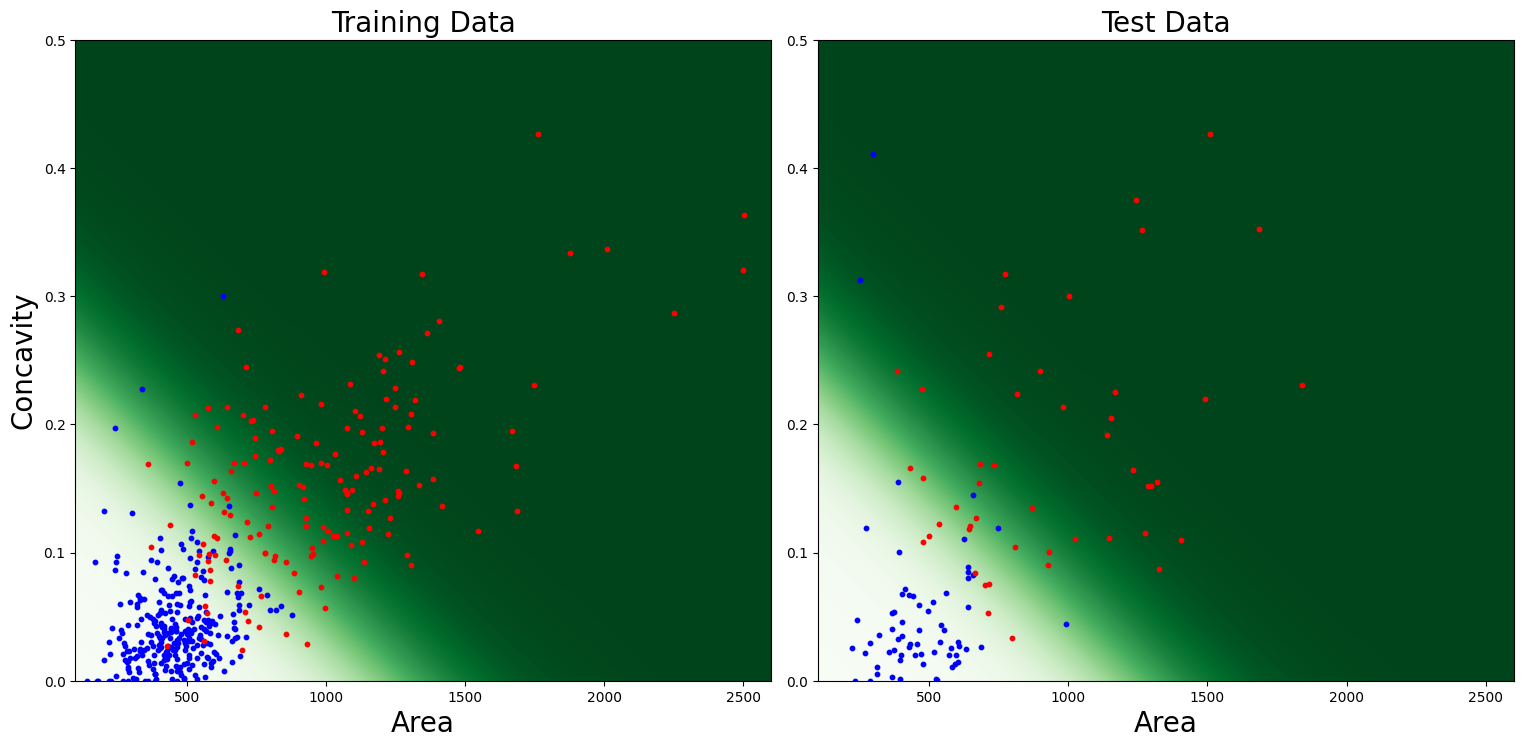

In [41]:
import matplotlib.cm as cm
from matplotlib import colormaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# cmap = cm.get_cmap('viridis')
# plt.figure(figsize=(12, 8))
cmap = colormaps["Greens"]
# cmap = colormaps["YlGn"] 
ax1.contourf(X1, X2, Z, levels=300, cmap=cmap)
scatter_data(ax1, X_train, y_train)

ax2.contourf(X1, X2, Z, levels=300, cmap=cmap)
# fig.colorbar()
scatter_data(ax2, X_test, y_test)
fig.tight_layout()
ax1.set_xlabel("Area", fontsize=20)
ax2.set_xlabel("Area", fontsize=20)

ax1.set_ylabel("Concavity", fontsize=20)
ax1.set_title("Training Data", fontsize=20)
ax2.set_title("Test Data", fontsize=20)

In [42]:
from sklearn.metrics import classification_report

def missclassification_rate(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return 1 - report['accuracy'] # Page 63 of textbook states, "1 minus the misclassification rate as the accuracy"

In [43]:
print(missclassification_rate(y_train, predictor.predict(X_train)))
print(missclassification_rate(y_test, predictor.predict(X_test)))

0.06593406593406592
0.13157894736842102


In [54]:
g_train

array([9.90853578e-01, 4.59834464e-01, 9.71679390e-01, 8.39894041e-01,
       9.93900956e-01, 9.97767869e-01, 9.50745852e-01, 6.45083992e-01,
       6.95950230e-01, 8.85851752e-01, 9.65414964e-01, 9.97277083e-01,
       9.52968756e-01, 9.80289224e-01, 9.72632343e-01, 9.79399979e-01,
       9.91899737e-01, 9.70306799e-01, 8.67241978e-02, 5.86345372e-01,
       1.62758091e-01, 9.77033764e-01, 9.89912506e-01, 9.58875415e-01,
       7.10058973e-02, 9.75527270e-01, 9.22104100e-01, 8.53610897e-01,
       9.67691280e-01, 9.51766209e-01, 9.05976577e-01, 8.35020215e-01,
       9.76782818e-01, 9.81050868e-01, 9.76173766e-01, 9.92105568e-01,
       9.85603483e-01, 6.25672267e-01, 5.01103865e-02, 6.91192051e-01,
       1.89246658e-01, 6.48496749e-01, 9.89873382e-01, 9.89973722e-01,
       6.99584131e-03, 9.82937501e-01, 9.85760971e-01, 9.65552471e-01,
       9.31592647e-01, 9.22029183e-03, 9.59493448e-01, 6.10242404e-01,
       9.54703315e-01, 9.89294499e-01, 4.58515639e-01, 2.19407609e-01,
      

In [63]:
@np.vectorize
def cross_entropy_loss(y, g):
    if y == 1:
        return np.log(g)
    elif y==-1:
        return np.log(1-g)


g_train = predictor.predict_proba(X_train)[:, 1]
g_test = predictor.predict_proba(X_test)[:, 1]
print(-np.mean(cross_entropy_loss(y_train, g_train)))
print(-np.mean(cross_entropy_loss(y_test, g_test)))

0.2096411187350794
0.29739464387752906


In [25]:
from sklearn.metrics import classification_report

def missclassification_rate(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return 1 - report['accuracy'] # Page 63 of textbook states, "1 minus the misclassification rate as the accuracy"



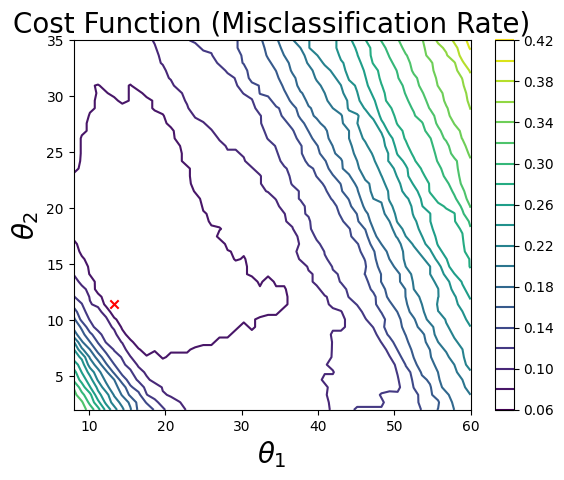

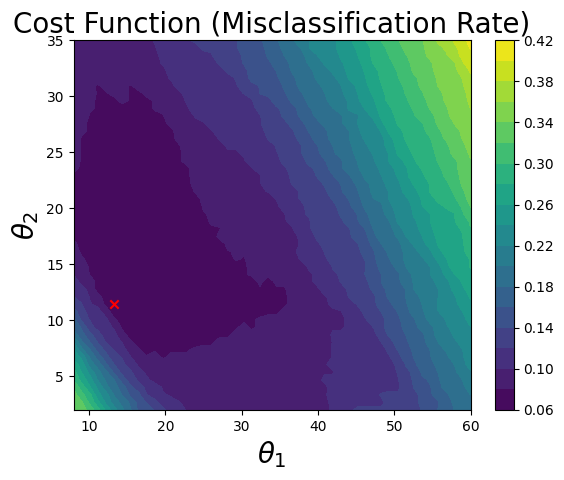

In [26]:
contour = plt.contour(THETA1, THETA2, J, levels=num_levels,zorder=0)
plt.scatter(coefs[0,0], coefs[0, 1], color="red", zorder=10, marker="x")
plt.colorbar(contour)
plt.xlabel(r"$\theta_1$", fontsize=20)
plt.ylabel(r"$\theta_2$", fontsize=20)
plt.title("Cost Function (Misclassification Rate)", fontsize=20)

plt.show()

contour = plt.contourf(THETA1, THETA2, J, levels=num_levels,zorder=0)
plt.scatter(coefs[0,0], coefs[0, 1], color="red", zorder=10, marker="x")
plt.colorbar(contour)
plt.xlabel(r"$\theta_1$", fontsize=20)
plt.ylabel(r"$\theta_2$", fontsize=20)
plt.title("Cost Function (Misclassification Rate)", fontsize=20)

plt.show()
# contour =plt.contourf(THETA1, THETA2, J, levels=500,zorder=0)
# plt.colorbar(contour)
# plt.scatter(theta1_opt, theta2_opt, zorder=10, marker="*")

In [27]:
# from sklearn.metrics import classification_report

# def missclassification_rate(y_true, y_pred):
#     report = classification_report(y_true, y_pred, output_dict=True)
#     return 1 - report['accuracy'] # Page 63 of textbook states, "1 minus the misclassification rate as the accuracy"

# @np.vectorize
# def calculate_cost_function(theta_1, theta_2, intercept):
#     predictor.classifier.intercept_ = intercept
#     predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
#     J = missclassification_rate(y_train, predictor.predict(X_train))
#     return J

# J = calculate_cost_function(THETA1, THETA2, intercepts*0+intercept_opt)

# contour = plt.contour(THETA1, THETA2, J, levels=45,zorder=0)
# plt.scatter(theta1_opt, theta2_opt, zorder=10)
# plt.colorbar(contour)

# plt.show()
# # contour =plt.contourf(THETA1, THETA2, J, levels=500,zorder=0)
# # plt.colorbar(contour)
# # plt.scatter(theta1_opt, theta2_opt, zorder=10, marker="*")
# # plt.xlim([20, 40])
# # plt.ylim([5, 15])

In [28]:
# predictor.classifier.intercept_ = intercept_opt
# predictor.classifier.coef_ = np.array([[theta1_opt, theta2_opt]])
# @np.vectorize
# def calculate_Z(x, y):
#     # print(predictor.classifier.coef_)
#     return predictor.predict_proba(np.array([[x, y]]))[0][1]

# x1 = np.linspace(100, 2600, 1000)
# x2 = np.linspace(0, 0.5, 1000)
# X1, X2 = np.meshgrid(x1, x2)
# Z = calculate_Z(X1, X2)

In [29]:
# predictor.classifier.intercept_ = intercept_opt
# predictor.classifier.coef_ = np.array([[theta1_opt, theta2_opt]])
# missclassification_rate(y_train, predictor.predict(X_train))

In [30]:
# predictor.score(X_train, y_train)

In [31]:
THETA2

array([[ 2.        ,  2.        ,  2.        , ...,  2.        ,
         2.        ,  2.        ],
       [ 2.67346939,  2.67346939,  2.67346939, ...,  2.67346939,
         2.67346939,  2.67346939],
       [ 3.34693878,  3.34693878,  3.34693878, ...,  3.34693878,
         3.34693878,  3.34693878],
       ...,
       [33.65306122, 33.65306122, 33.65306122, ..., 33.65306122,
        33.65306122, 33.65306122],
       [34.32653061, 34.32653061, 34.32653061, ..., 34.32653061,
        34.32653061, 34.32653061],
       [35.        , 35.        , 35.        , ..., 35.        ,
        35.        , 35.        ]], shape=(50, 50))